# Task 1 — Data Loading, Merging & Deep Exploration

In this task, the Superstore Sales dataset is loaded and explored to understand its structure, data quality, sales patterns, regional performance, shipping behavior, and seasonality.

In [1]:
# Import Pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Load the Superstore Sales dataset
df = pd.read_csv("train.csv")

# Display the first 5 rows of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
import os

os.makedirs("charts", exist_ok=True)

In [ ]:
# Parse Order Date and Ship Date as proper datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [4]:
# Extract Year, Month, Week Number, Day of Week, Quarter, and Season
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df[
    [
        "Order Date",
        "Year",
        "Month",
        "Week Number",
        "Day of Week",
        "Quarter",
        "Season"
    ]
].head()

,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,41,Tuesday,4,Autumn


In [5]:
# Check for missing values, duplicates, and data type issues
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Duplicate Rows:
0

Data Types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category   

In [6]:
# Aggregate daily sales into weekly and monthly totals
weekly_sales = (
    df.set_index("Order Date")["Sales"]
    .resample("W")
    .sum()
    .reset_index()
)

monthly_sales = (
    df.set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
    .reset_index()
)

print("Weekly Sales:")
display(weekly_sales.head())

print("\nMonthly Sales:")
display(monthly_sales.head())

Weekly Sales:


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914



Monthly Sales:


,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [7]:
# Find which product category generates the highest total revenue
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)

print(
    "Highest Revenue Category:",
    category_sales.idxmax()
)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Highest Revenue Category: Technology


In [8]:
# Find which region has the most consistent sales growth over 4 years
region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
    .sum()
    .unstack()
)

region_growth = region_year_sales.pct_change(fill_method=None) * 100

growth_variation = region_growth.std()

display(region_year_sales)
display(region_growth)

print(
    "Most Consistent Sales Growth Region:",
    growth_variation.idxmin()
)

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


Region,Central,East,South,West
Year,,,,
2015,NaN,NaN,NaN,NaN
2016,-0.481292,20.032745,-32.211708,-8.360336
2017,42.224686,16.502741,33.477643,36.468341
2018,-2.777807,17.711823,30.607139,35.983589


Most Consistent Sales Growth Region: East


In [9]:
# Find whether any months consistently show sales spikes across all years
year_month_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales_pivot = year_month_sales.pivot(
    index="Month",
    columns="Year",
    values="Sales"
)

display(monthly_sales_pivot)

top_months_each_year = monthly_sales_pivot.rank(
    ascending=False
) <= 3

spike_count = top_months_each_year.sum(axis=1).sort_values(
    ascending=False
)

display(spike_count)

print(
    "Month with the most consistent sales spike:",
    spike_count.idxmax()
)

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


Month
12    4
9     4
11    4
1     0
4     0
3     0
2     0
5     0
8     0
7     0
6     0
10    0
dtype: int64

Month with the most consistent sales spike: 12


In [10]:
# Q4: Are there months that consistently spike across all years (Seasonality)?

monthly_seasonality = (
    df.groupby("Month")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Sales by Month:")
print(monthly_seasonality)

print("\nHighest Average Sales Month:", monthly_seasonality.idxmax())
print("Average Sales:", round(monthly_seasonality.max(), 2))

print(f"\nConclusion: Month {monthly_seasonality.idxmax()} shows the highest average sales across all years, indicating a seasonal sales spike.")

Average Sales by Month:
Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64

Highest Average Sales Month: 3
Average Sales: 290.55

Conclusion: Month 3 shows the highest average sales across all years, indicating a seasonal sales spike.


# Task 2 — Time Series Analysis & Decomposition

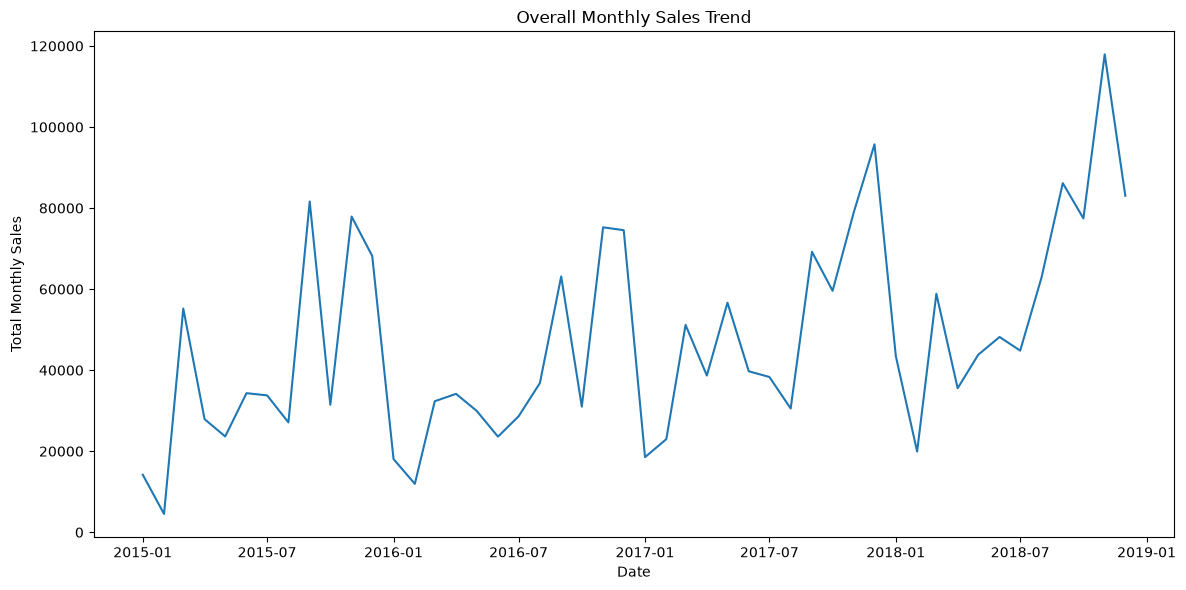

In [11]:
# Plot the overall monthly sales trend across all 4 years
import matplotlib.pyplot as plt

monthly_sales_series = (
    df.set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_series.index, monthly_sales_series.values)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")

plt.tight_layout()

plt.savefig(
    "Charts/overall_monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

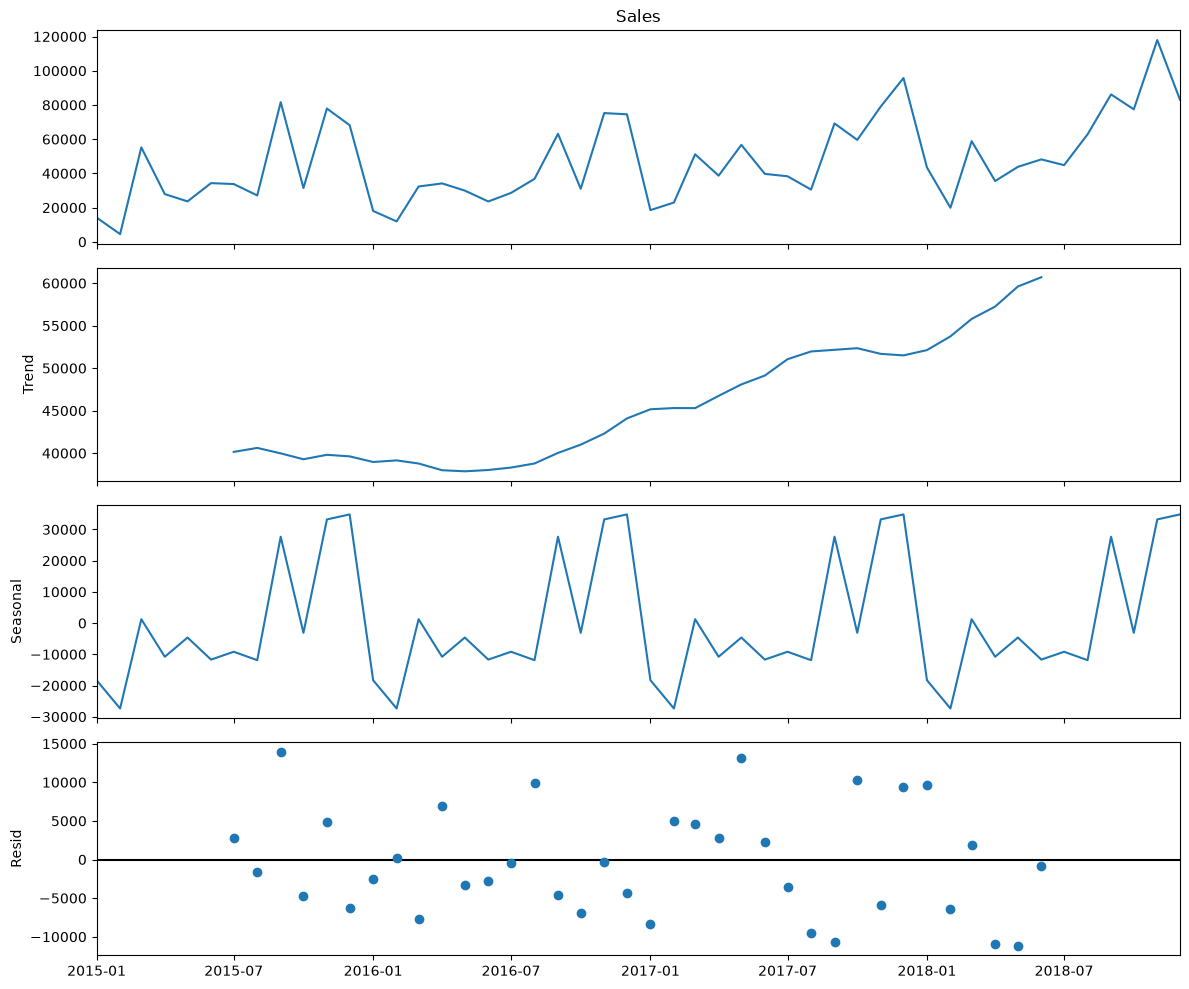

In [12]:
# Apply Time Series Decomposition to separate trend, seasonal, and residual components
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales_series,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 10)

plt.tight_layout()
plt.savefig(
    "charts/Sales.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [13]:
# Display 4 observations from the decomposition results
trend = decomposition.trend.dropna()
seasonal = decomposition.seasonal
residual = decomposition.resid.dropna()

print("1. Trend Observation:")

if trend.iloc[-1] > trend.iloc[0]:
    print("The overall sales trend shows an increase over time.")
else:
    print("The overall sales trend shows a decrease over time.")


print("\n2. Seasonality Observation:")

seasonal_range = seasonal.max() - seasonal.min()

print(
    f"The seasonal component has a variation range of "
    f"{seasonal_range:.2f}, indicating recurring seasonal patterns."
)


print("\n3. Highest Residual Noise Months:")

highest_residuals = residual.abs().nlargest(3)

display(highest_residuals)


print("\n4. Residual Observation:")

print(
    "Large residual values represent unusual sales changes "
    "that are not explained by trend or seasonality."
)

1. Trend Observation:
The overall sales trend shows an increase over time.

2. Seasonality Observation:
The seasonal component has a variation range of 62195.01, indicating recurring seasonal patterns.

3. Highest Residual Noise Months:


Order Date
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
Name: resid, dtype: float64


4. Residual Observation:
Large residual values represent unusual sales changes that are not explained by trend or seasonality.


In [14]:
# Check stationarity using the Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales_series.dropna())

print("ADF Statistic:", adf_result[0])

print("P-value:", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(key, ":", value)


if adf_result[1] <= 0.05:

    print(
        "\nThe monthly sales series is stationary because "
        "the p-value is less than or equal to 0.05."
    )

else:

    print(
        "\nThe monthly sales series is non-stationary because "
        "the p-value is greater than 0.05."
    )

ADF Statistic: -4.416136761430769
P-value: 0.00027791039276670623

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064

The monthly sales series is stationary because the p-value is less than or equal to 0.05.


In [15]:
# Apply differencing if the series is non-stationary and perform the ADF Test again
if adf_result[1] > 0.05:

    differenced_sales = monthly_sales_series.diff().dropna()

    second_adf_result = adfuller(differenced_sales)

    print("ADF Statistic After Differencing:", second_adf_result[0])

    print("P-value After Differencing:", second_adf_result[1])


    if second_adf_result[1] <= 0.05:

        print(
            "\nThe sales series is stationary after differencing."
        )

    else:

        print(
            "\nThe sales series is still non-stationary after differencing."
        )

else:

    print("Differencing is not required because the original series is stationary.")
    

Differencing is not required because the original series is stationary.


# Task 3 — Sales Forecasting Using Three Different Models

This task develops and compares three forecasting models to predict future monthly sales. A SARIMA model, Facebook Prophet model, and XGBoost Regressor are trained and evaluated using MAE, RMSE, and MAPE. The best-performing model is selected based on evaluation metrics and used for forecasting the next three months.

In [16]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Create monthly sales time series
monthly_sales = (
    df.set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
)

# Split data into training and testing sets
train_size = int(len(monthly_sales) * 0.80)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

print("Training Samples:", len(train))
print("Testing Samples:", len(test))

display(train.head())
display(test.head())


Training Samples: 38
Testing Samples: 10


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

Order Date
2018-03-01    58863.4128
2018-04-01    35541.9101
2018-05-01    43825.9822
2018-06-01    48190.7277
2018-07-01    44825.1040
Freq: MS, Name: Sales, dtype: float64

In [17]:
# Import the SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train the SARIMA model
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

sarima_result = sarima_model.fit()

# Predict sales for the testing period
sarima_prediction = sarima_result.forecast(steps=len(test))

# Calculate evaluation metrics
sarima_mae = mean_absolute_error(test, sarima_prediction)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_prediction)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_prediction
) * 100

# Display evaluation metrics
print("SARIMA Model Performance")
print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

c:\Ai\E-Commerce\.venv-1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA Model Performance
MAE  : 11532.90
RMSE : 13843.49
MAPE : 17.65%


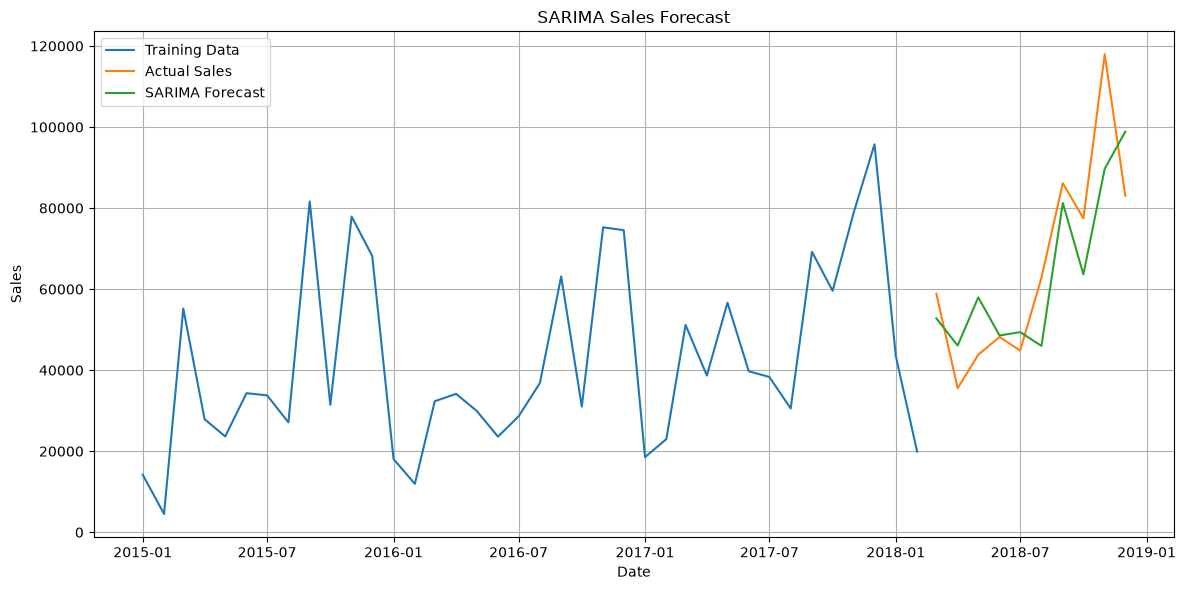

In [18]:
# Plot actual and predicted sales
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Sales"
)

plt.plot(
    test.index,
    sarima_prediction,
    label="SARIMA Forecast"
)

plt.title("SARIMA Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/SARIMA_Sales_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Generate a 3-month future forecast using the SARIMA model
future_forecast = sarima_result.get_forecast(
    steps=3
)

# Extract forecasted sales values
sarima_future = future_forecast.predicted_mean

# Extract confidence intervals
sarima_confidence = future_forecast.conf_int()

# Display the 3-month forecast
forecast_df = pd.DataFrame({
    "Forecast": sarima_future,
    "Lower Bound": sarima_confidence.iloc[:, 0],
    "Upper Bound": sarima_confidence.iloc[:, 1]
})

display(forecast_df)

,Forecast,Lower Bound,Upper Bound
2018-03-01,52784.841893,27375.884896,78193.798891
2018-04-01,46067.089461,15033.632318,77100.546603
2018-05-01,57964.457763,24198.769144,91730.146382


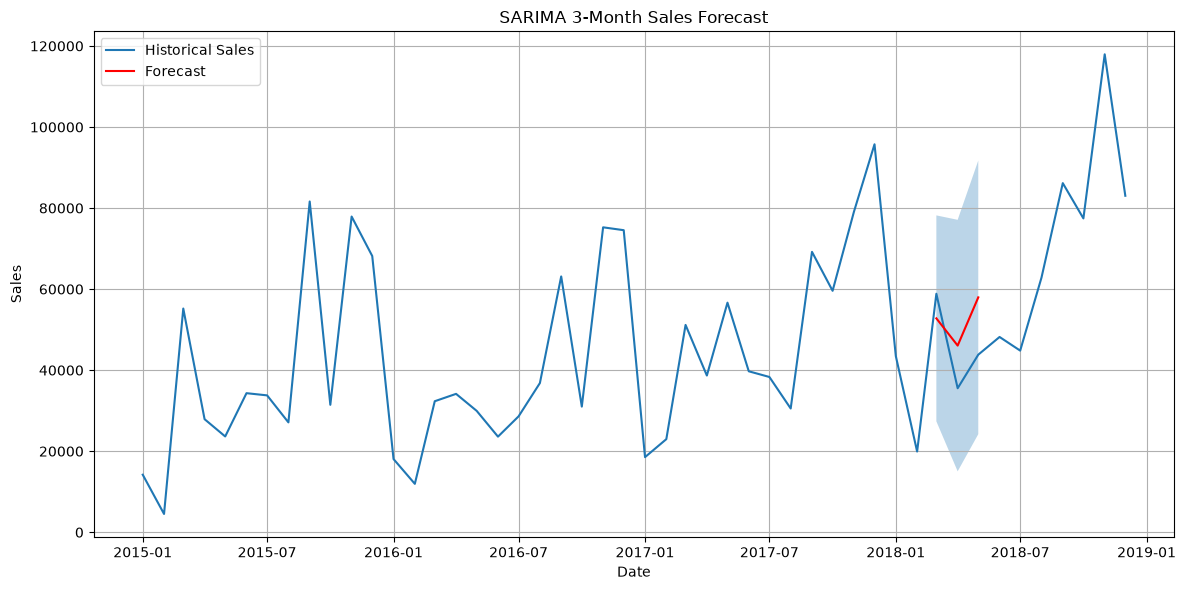

In [20]:
# Plot the 3-month future forecast with confidence intervals
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales,
    label="Historical Sales"
)

plt.plot(
    sarima_future.index,
    sarima_future,
    label="Forecast",
    color="red"
)

plt.fill_between(
    sarima_future.index,
    sarima_confidence.iloc[:,0],
    sarima_confidence.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA 3-Month Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/SARIMA_3-Month_Sales_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Import Prophet
from prophet import Prophet

# Prepare the data for Prophet
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

# Split the data into training and testing sets
prophet_train = prophet_df.iloc[:train_size]

prophet_test = prophet_df.iloc[train_size:]

# Create the Prophet model
prophet_model = Prophet()

# Train the Prophet model
prophet_model.fit(prophet_train)

# Create future dates for prediction
future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="MS"
)

# Predict future sales
forecast = prophet_model.predict(future)

# Extract predictions for the testing period
prophet_prediction = forecast["yhat"].iloc[-len(prophet_test):].values

# Calculate evaluation metrics
prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_prediction
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_prediction
    )
)

prophet_mape = (
    mean_absolute_percentage_error(
        prophet_test["y"],
        prophet_prediction
    ) * 100
)

# Display evaluation metrics
print("Prophet Model Performance")
print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}")

c:\Ai\E-Commerce\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
14:38:17 - cmdstanpy - INFO - Chain [1] start processing
14:38:18 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Performance
MAE  : 9988.63
RMSE : 14792.41
MAPE : 13.95


In [22]:
# Create future dates for prediction
future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="MS"
)

# Predict future sales
forecast = prophet_model.predict(future)

# Extract predictions for the testing period
prophet_prediction = forecast["yhat"].iloc[-len(prophet_test):].values

# Calculate evaluation metrics
prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_prediction
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_prediction
    )
)

prophet_mape = (
    mean_absolute_percentage_error(
        prophet_test["y"],
        prophet_prediction
    ) * 100
)

# Display evaluation metrics
print("Prophet Model Performance")

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}%")

Prophet Model Performance
MAE  : 9988.63
RMSE : 14792.41
MAPE : 13.95%


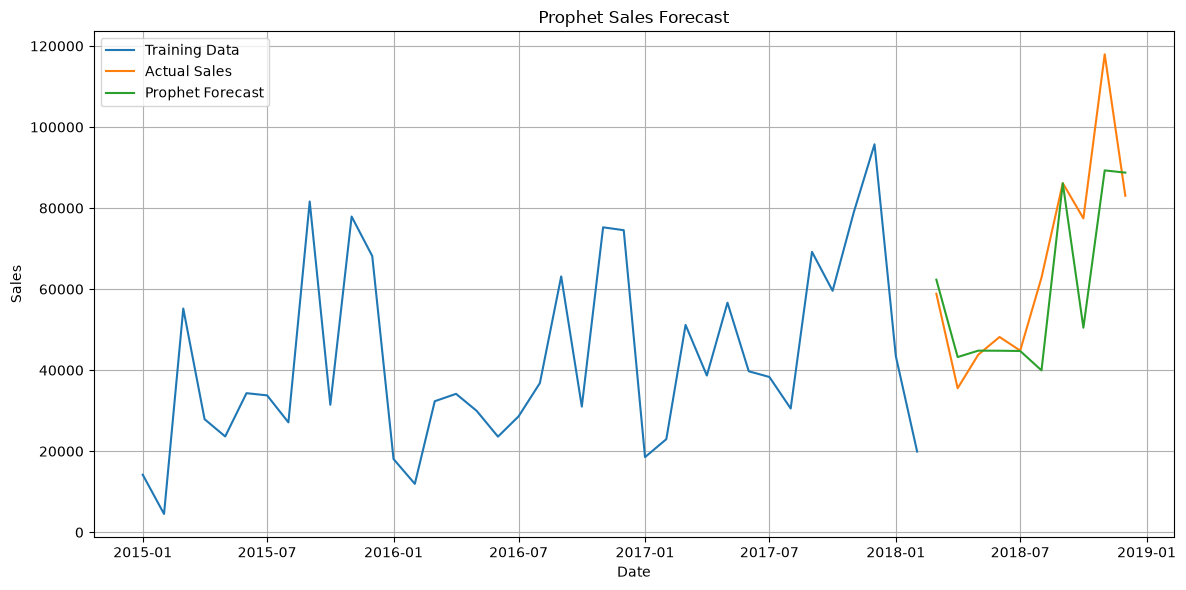

In [23]:
# Plot the actual and predicted sales
plt.figure(figsize=(12,6))

plt.plot(
    prophet_train["ds"],
    prophet_train["y"],
    label="Training Data"
)

plt.plot(
    prophet_test["ds"],
    prophet_test["y"],
    label="Actual Sales"
)

plt.plot(
    prophet_test["ds"],
    prophet_prediction,
    label="Prophet Forecast"
)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/Prophet_Sales_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

,ds,yhat,yhat_lower,yhat_upper
38,2018-03-01,62330.900835,54783.309527,70491.077676
39,2018-04-01,43235.540480,35279.959727,51341.244335
40,2018-05-01,44817.626575,36767.771377,52917.668643


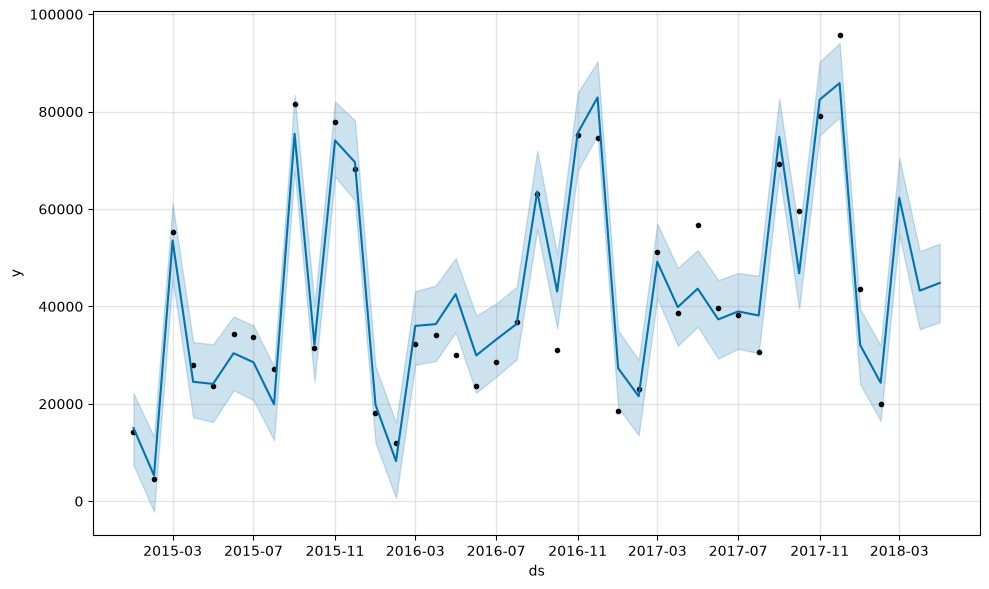

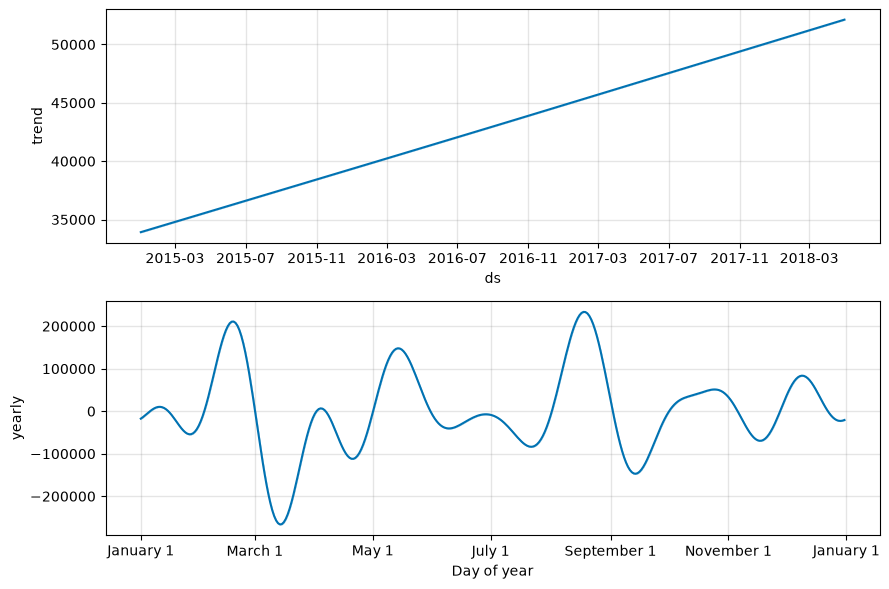

In [24]:
# Forecast the next 3 months
future_3 = prophet_model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast_3 = prophet_model.predict(future_3)

# Display the 3-month forecast
display(
    forecast_3[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].tail(3)
)

# Plot the forecast with trend and seasonality
prophet_model.plot(forecast_3)

plt.tight_layout()

plt.show()

# Plot the trend and seasonality components
prophet_model.plot_components(forecast_3)

plt.tight_layout()
plt.savefig(
    "charts/Prophet_3-Month_Sales_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Import the XGBoost Regressor
from xgboost import XGBRegressor

# Create a dataframe for feature engineering
xgb_data = monthly_sales.reset_index()

# Rename the Sales column
xgb_data.columns = ["Order Date", "Sales"]

# Extract Year, Month, and Quarter
xgb_data["Year"] = xgb_data["Order Date"].dt.year
xgb_data["Month"] = xgb_data["Order Date"].dt.month
xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

# Create lag features
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

# Create a rolling mean feature
xgb_data["Rolling_Mean_3"] = (
    xgb_data["Sales"]
    .rolling(window=3)
    .mean()
)

# Remove missing values
xgb_data = xgb_data.dropna()

display(xgb_data.head())

,Order Date,Sales,Year,Month,Quarter,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
3,2015-04-01,27906.8550,2015,4,2,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-01,23644.3030,2015,5,2,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-01,34322.9356,2015,6,2,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-01,33781.5430,2015,7,3,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-01,27117.5365,2015,8,3,33781.5430,34322.9356,23644.303,31740.671700


In [26]:
# Select the input features
X = xgb_data[
    [
        "Year",
        "Month",
        "Quarter",
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3"
    ]
]

# Select the target variable
y = xgb_data["Sales"]

# Split the dataset into training and testing sets
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Create the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict the testing data
xgb_prediction = xgb_model.predict(X_test)

# Calculate evaluation metrics
xgb_mae = mean_absolute_error(
    y_test,
    xgb_prediction
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_prediction
    )
)

xgb_mape = (
    mean_absolute_percentage_error(
        y_test,
        xgb_prediction
    ) * 100
)

# Display evaluation metrics
print("XGBoost Model Performance")

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2f}%")

XGBoost Model Performance
MAE  : 8552.13
RMSE : 13244.02
MAPE : 11.55%


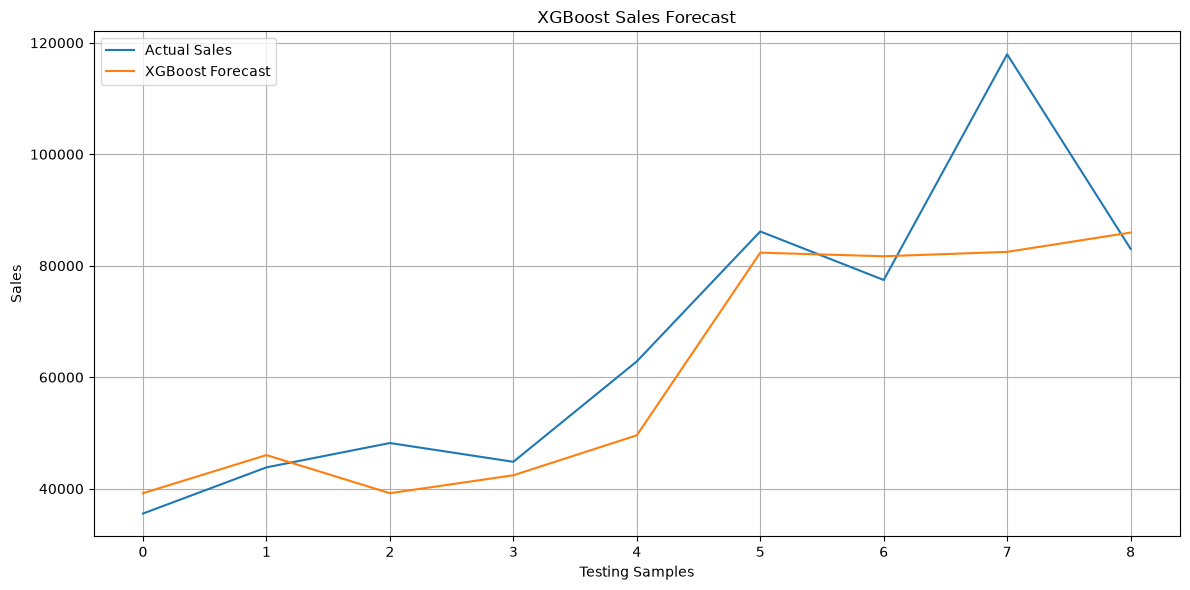

In [27]:
# Plot the actual and predicted sales
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    xgb_prediction,
    label="XGBoost Forecast"
)

plt.title("XGBoost Sales Forecast")

plt.xlabel("Testing Samples")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/XGBoost Sales Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Forecast the next 3 months using the XGBoost model
future_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.DateOffset(months=1),
    periods=3,
    freq="MS"
)

future_predictions = []

last_sales = list(monthly_sales.tail(3).values)

for date in future_dates:

    future_input = pd.DataFrame({
        "Year": [date.year],
        "Month": [date.month],
        "Quarter": [date.quarter],
        "Lag_1": [last_sales[-1]],
        "Lag_2": [last_sales[-2]],
        "Lag_3": [last_sales[-3]],
        "Rolling_Mean_3": [np.mean(last_sales)]
    })

    prediction = xgb_model.predict(future_input)[0]

    future_predictions.append(prediction)

    last_sales.append(prediction)
    last_sales.pop(0)

# Create the forecast dataframe
future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
})

display(future_forecast)

,Date,Forecast
0,2019-01-01,51421.320312
1,2019-02-01,52153.843750
2,2019-03-01,68908.507812


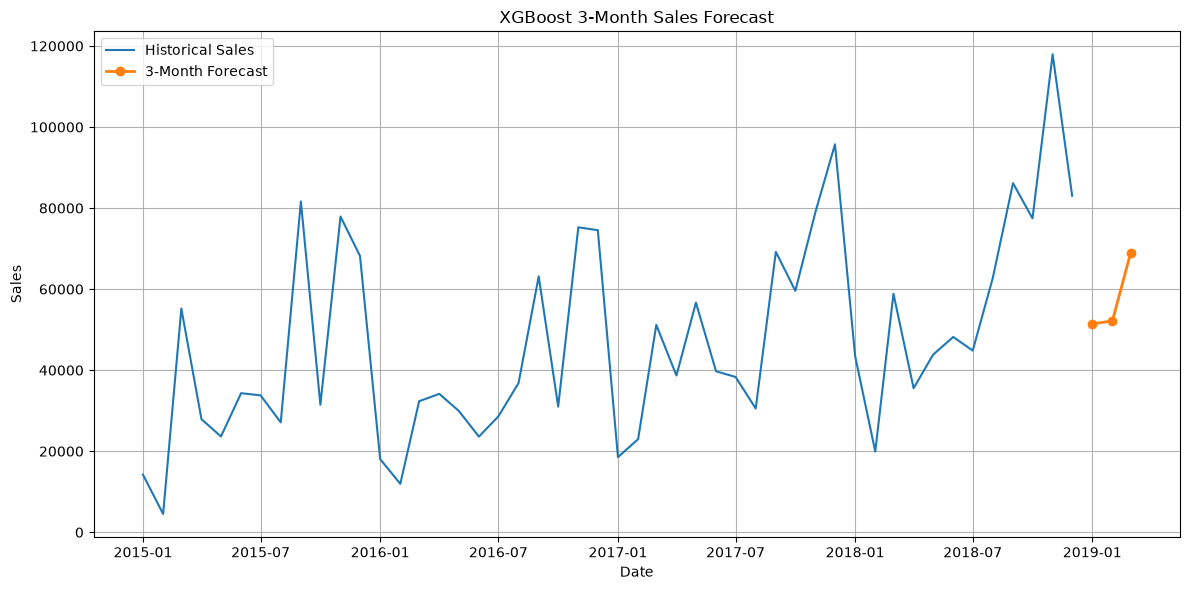

In [29]:
# Plot the historical sales and XGBoost forecast
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Historical Sales"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecast"],
    marker="o",
    linewidth=2,
    label="3-Month Forecast"
)

plt.title("XGBoost 3-Month Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
# Compare all forecasting models
comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],
    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],
    "MAPE": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]
})

# Display the comparison table
display(comparison)

# Identify the best forecasting model
best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("Best Forecasting Model:", best_model)

,Model,MAE,RMSE,MAPE
0,SARIMA,11532.900685,13843.493231,17.652653
1,Prophet,9988.634786,14792.407750,13.950200
2,XGBoost,8552.129541,13244.019225,11.551457


Best Forecasting Model: XGBoost


# Task 4 — Product Category and Regional Sales Forecasting

In [31]:
# Calculate monthly sales for each product category
category_sales = (
    df.groupby(["Order Date", "Category"])["Sales"]
    .sum()
    .reset_index()
)

category_sales["Order Date"] = pd.to_datetime(
    category_sales["Order Date"]
)

category_monthly = (
    category_sales
    .groupby(
        [
            pd.Grouper(
                key="Order Date",
                freq="MS"
            ),
            "Category"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

display(category_monthly.head())

,Order Date,Category,Sales
0,2015-01-01,Furniture,6217.277
1,2015-01-01,Office Supplies,4845.140
2,2015-01-01,Technology,3143.290
3,2015-02-01,Furniture,1839.658
4,2015-02-01,Office Supplies,1071.724


In [32]:
# Forecast the next 3 months for each product category
from prophet import Prophet

category_forecasts = {}

for category in category_monthly["Category"].unique():

    category_df = category_monthly[
        category_monthly["Category"] == category
    ][["Order Date", "Sales"]]

    category_df.columns = ["ds", "y"]

    model = Prophet()

    model.fit(category_df)

    future = model.make_future_dataframe(
        periods=3,
        freq="MS"
    )

    forecast = model.predict(future)

    category_forecasts[category] = forecast[
        ["ds", "yhat"]
    ].tail(3)

for category in category_forecasts:

    print(f"\n{category}")

    display(category_forecasts[category])

14:38:24 - cmdstanpy - INFO - Chain [1] start processing
14:38:24 - cmdstanpy - INFO - Chain [1] done processing
14:38:24 - cmdstanpy - INFO - Chain [1] start processing
14:38:24 - cmdstanpy - INFO - Chain [1] done processing
14:38:25 - cmdstanpy - INFO - Chain [1] start processing
14:38:25 - cmdstanpy - INFO - Chain [1] done processing



Furniture


,ds,yhat
48,2019-01-01,12703.027818
49,2019-02-01,7686.983287
50,2019-03-01,16989.046333



Office Supplies


,ds,yhat
48,2019-01-01,14508.928486
49,2019-02-01,12500.104406
50,2019-03-01,19421.521948



Technology


,ds,yhat
48,2019-01-01,13815.845691
49,2019-02-01,11356.808224
50,2019-03-01,42215.823823


In [33]:
# Calculate monthly sales for each region
region_sales = (
    df.groupby(["Order Date", "Region"])["Sales"]
    .sum()
    .reset_index()
)

region_sales["Order Date"] = pd.to_datetime(
    region_sales["Order Date"]
)

region_monthly = (
    region_sales
    .groupby(
        [
            pd.Grouper(
                key="Order Date",
                freq="MS"
            ),
            "Region"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

display(region_monthly.head())

,Order Date,Region,Sales
0,2015-01-01,Central,1533.966
1,2015-01-01,East,436.174
2,2015-01-01,South,9296.844
3,2015-01-01,West,2938.723
4,2015-02-01,Central,1233.174


In [34]:
# Forecast the next 3 months for each region
region_forecasts = {}

for region in region_monthly["Region"].unique():

    region_df = region_monthly[
        region_monthly["Region"] == region
    ][["Order Date", "Sales"]]

    region_df.columns = ["ds", "y"]

    model = Prophet()

    model.fit(region_df)

    future = model.make_future_dataframe(
        periods=3,
        freq="MS"
    )

    forecast = model.predict(future)

    region_forecasts[region] = forecast[
        ["ds", "yhat"]
    ].tail(3)

for region in region_forecasts:

    print(f"\n{region}")

    display(region_forecasts[region])

14:38:25 - cmdstanpy - INFO - Chain [1] start processing
14:38:26 - cmdstanpy - INFO - Chain [1] done processing
14:38:26 - cmdstanpy - INFO - Chain [1] start processing
14:38:26 - cmdstanpy - INFO - Chain [1] done processing
14:38:26 - cmdstanpy - INFO - Chain [1] start processing
14:38:27 - cmdstanpy - INFO - Chain [1] done processing
14:38:27 - cmdstanpy - INFO - Chain [1] start processing
14:38:27 - cmdstanpy - INFO - Chain [1] done processing



Central


,ds,yhat
48,2019-01-01,10608.876638
49,2019-02-01,6699.829009
50,2019-03-01,16051.770950



East


,ds,yhat
48,2019-01-01,9412.424812
49,2019-02-01,10128.314904
50,2019-03-01,14478.008751



South


,ds,yhat
48,2019-01-01,6858.520309
49,2019-02-01,3390.422086
50,2019-03-01,22169.548212



West


,ds,yhat
48,2019-01-01,14626.053340
49,2019-02-01,11907.970617
50,2019-03-01,26432.585958


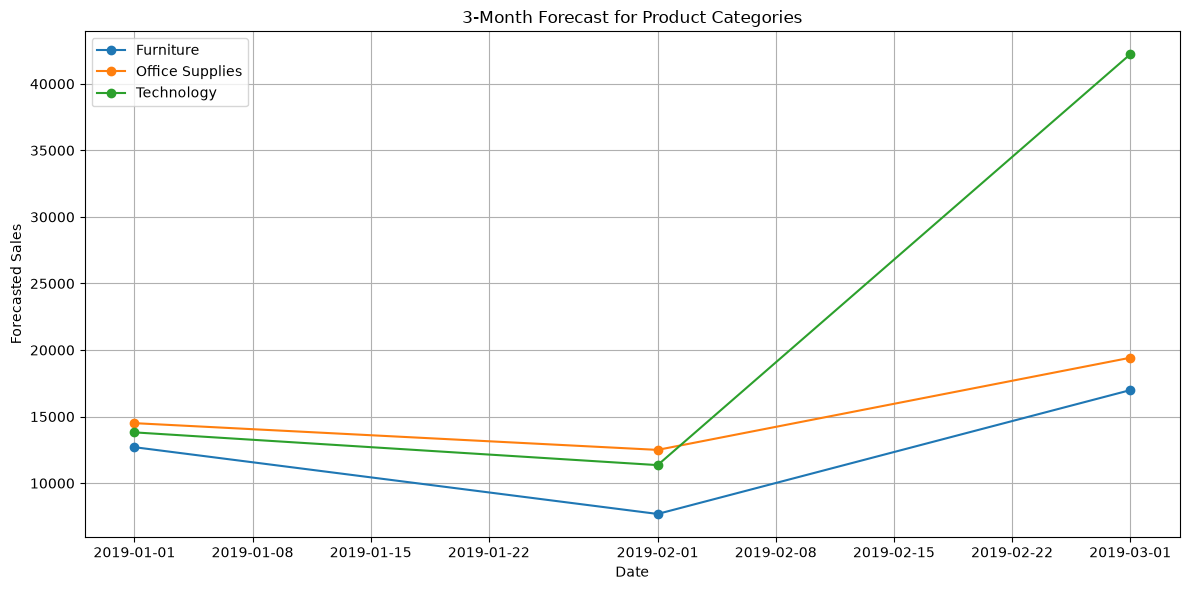

In [35]:
# Plot the forecast for all product categories
plt.figure(figsize=(12,6))

for category in category_forecasts:

    plt.plot(
        category_forecasts[category]["ds"],
        category_forecasts[category]["yhat"],
        marker="o",
        label=category
    )

plt.title("3-Month Forecast for Product Categories")

plt.xlabel("Date")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/Product_Category_Forecasts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

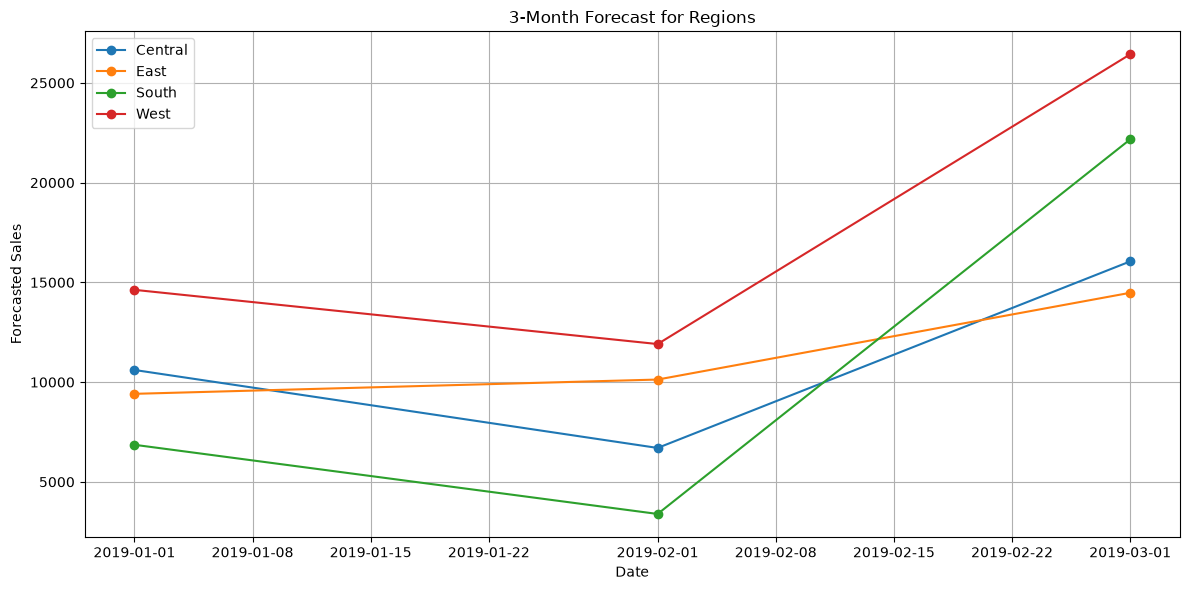

In [36]:
# Plot the forecast for all regions
plt.figure(figsize=(12,6))

for region in region_forecasts:

    plt.plot(
        region_forecasts[region]["ds"],
        region_forecasts[region]["yhat"],
        marker="o",
        label=region
    )

plt.title("3-Month Forecast for Regions")

plt.xlabel("Date")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/Region_Forecasts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Identify the category with the highest forecasted sales
category_growth = {}

for category in category_forecasts:

    category_growth[category] = (
        category_forecasts[category]["yhat"]
        .iloc[-1]
    )

category_growth = pd.Series(category_growth)

display(category_growth.sort_values(ascending=False))

best_category = category_growth.idxmax()

print(
    "Category Showing the Strongest Growth:",
    best_category
)




Technology         42215.823823
Office Supplies    19421.521948
Furniture          16989.046333
dtype: float64

Category Showing the Strongest Growth: Technology


In [38]:
# Identify the region with the highest forecasted sales
region_growth = {}

for region in region_forecasts:

    region_growth[region] = (
        region_forecasts[region]["yhat"]
        .iloc[-1]
    )

region_growth = pd.Series(region_growth)

display(region_growth.sort_values(ascending=False))

best_region = region_growth.idxmax()

print(
    "Region Showing the Strongest Growth:",
    best_region
)

West       26432.585958
South      22169.548212
Central    16051.770950
East       14478.008751
dtype: float64

Region Showing the Strongest Growth: West


# Task 5 — Anomaly Detection in Sales Data

In [39]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [40]:
# Load the supplementary dataset
vg_df = pd.read_csv("vgsales.csv")

display(vg_df.head())

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [41]:
# Explore the supplementary dataset
print(vg_df.info())

display(vg_df.describe())

print(vg_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB
None


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [42]:
# Clean the supplementary dataset
vg_df = vg_df.dropna()

vg_df["Year"] = vg_df["Year"].astype(int)

display(vg_df.head())

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [43]:
# Aggregate yearly sales from the Superstore dataset
superstore_yearly = (
    df.groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

display(superstore_yearly)

,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


In [44]:
# Aggregate yearly global sales from the Video Game Sales dataset
vg_yearly = (
    vg_df.groupby("Year")["Global_Sales"]
    .sum()
    .reset_index()
)

display(vg_yearly)

,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


In [45]:
# Merge the two datasets using the Year column
merged_data = pd.merge(
    superstore_yearly,
    vg_yearly,
    on="Year",
    how="inner"
)

display(merged_data)

,Year,Sales,Global_Sales
0,2015,479856.2081,264.44
1,2016,459436.0054,70.90
2,2017,600192.5500,0.05


In [46]:
# Detect anomalies using Isolation Forest
iso_model = IsolationForest(
    contamination=0.10,
    random_state=42
)

merged_data["Anomaly"] = iso_model.fit_predict(
    merged_data[
        [
            "Sales",
            "Global_Sales"
        ]
    ]
)

merged_data["Anomaly"] = (
    merged_data["Anomaly"] == -1
)

display(merged_data)

,Year,Sales,Global_Sales,Anomaly
0,2015,479856.2081,264.44,False
1,2016,459436.0054,70.90,False
2,2017,600192.5500,0.05,True


In [47]:
# Detect anomalies using the Z-Score method
merged_data["Sales_ZScore"] = zscore(
    merged_data["Sales"]
)

merged_data["VG_ZScore"] = zscore(
    merged_data["Global_Sales"]
)

merged_data["ZScore_Anomaly"] = (
    (merged_data["Sales_ZScore"].abs() > 2) |
    (merged_data["VG_ZScore"].abs() > 2)
)

display(merged_data)

,Year,Sales,Global_Sales,Anomaly,Sales_ZScore,VG_ZScore,ZScore_Anomaly
0,2015,479856.2081,264.44,False,-0.536299,1.366015,False
1,2016,459436.0054,70.90,False,-0.865115,-0.365987,False
2,2017,600192.5500,0.05,True,1.401414,-1.000028,False


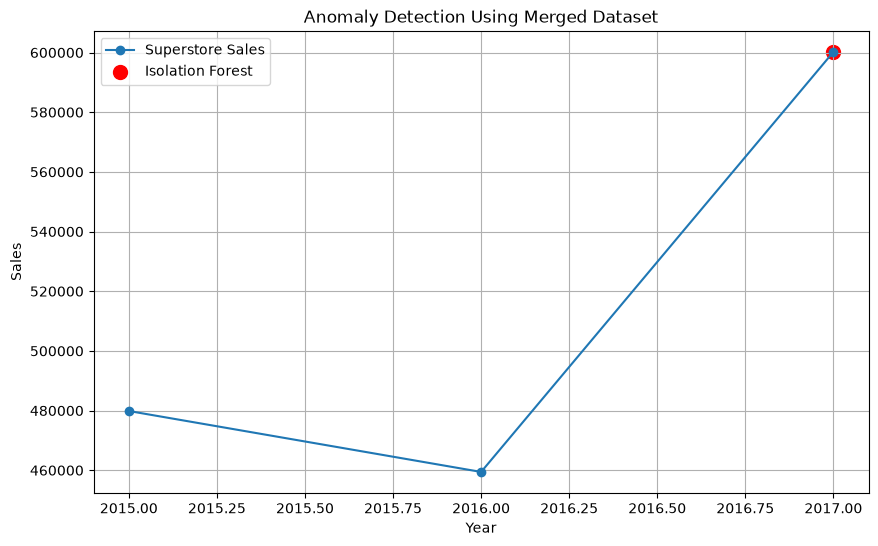

In [48]:
# Visualize anomalies
plt.figure(figsize=(10,6))

plt.plot(
    merged_data["Year"],
    merged_data["Sales"],
    marker="o",
    label="Superstore Sales"
)

plt.scatter(
    merged_data[
        merged_data["Anomaly"]
    ]["Year"],
    merged_data[
        merged_data["Anomaly"]
    ]["Sales"],
    color="red",
    s=100,
    label="Isolation Forest"
)

plt.title("Anomaly Detection Using Merged Dataset")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)
plt.savefig(
    "charts/Anomaly_Detection.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [49]:
# Display anomaly summary
print("Merged Dataset Shape :", merged_data.shape)

print(
    "Isolation Forest Anomalies :",
    merged_data["Anomaly"].sum()
)

print(
    "Z-Score Anomalies :",
    merged_data["ZScore_Anomaly"].sum()
)

display(
    merged_data[
        merged_data["Anomaly"] |
        merged_data["ZScore_Anomaly"]
    ]
)

Merged Dataset Shape : (3, 7)
Isolation Forest Anomalies : 1
Z-Score Anomalies : 0


,Year,Sales,Global_Sales,Anomaly,Sales_ZScore,VG_ZScore,ZScore_Anomaly
2,2017,600192.55,0.05,True,1.401414,-1.000028,False


# Task 6 — Product Demand Segmentation Using Clustering
```

In [50]:
# Aggregate sales at the product sub-category level
subcategory_data = (
    df.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Average_Sales=("Sales", "mean"),
        Sales_Volatility=("Sales", "std"),
        Order_Count=("Sales", "count")
    )
    .reset_index()
)

display(subcategory_data.head())

,Sub-Category,Total_Sales,Average_Sales,Sales_Volatility,Order_Count
0,Accessories,164186.7000,217.178175,337.723800,756
1,Appliances,104618.4030,227.926804,378.006735,459
2,Art,26705.4100,34.019631,60.301752,785
3,Binders,200028.7850,134.067550,568.099970,1492
4,Bookcases,113813.1987,503.598224,641.419280,226


In [51]:
# Calculate Year-over-Year sales growth for each sub-category
yearly_sales = (
    df.groupby(["Year", "Sub-Category"])["Sales"]
    .sum()
    .reset_index()
)

yearly_sales["Sales_Growth"] = (
    yearly_sales.groupby("Sub-Category")["Sales"]
    .pct_change() * 100
)

growth_data = (
    yearly_sales.groupby("Sub-Category")["Sales_Growth"]
    .mean()
    .reset_index()
)

subcategory_data = subcategory_data.merge(
    growth_data,
    on="Sub-Category",
    how="left"
)

subcategory_data.fillna(0, inplace=True)

display(subcategory_data.head())

,Sub-Category,Total_Sales,Average_Sales,Sales_Volatility,Order_Count,Sales_Growth
0,Accessories,164186.7000,217.178175,337.723800,756,37.638071
1,Appliances,104618.4030,227.926804,378.006735,459,39.927584
2,Art,26705.4100,34.019631,60.301752,785,16.605553
3,Binders,200028.7850,134.067550,568.099970,1492,21.873607
4,Bookcases,113813.1987,503.598224,641.419280,226,23.806516


In [52]:
# Scale the features before clustering
from sklearn.preprocessing import StandardScaler

features = subcategory_data[
    [
        "Total_Sales",
        "Average_Sales",
        "Sales_Volatility",
        "Order_Count",
        "Sales_Growth"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

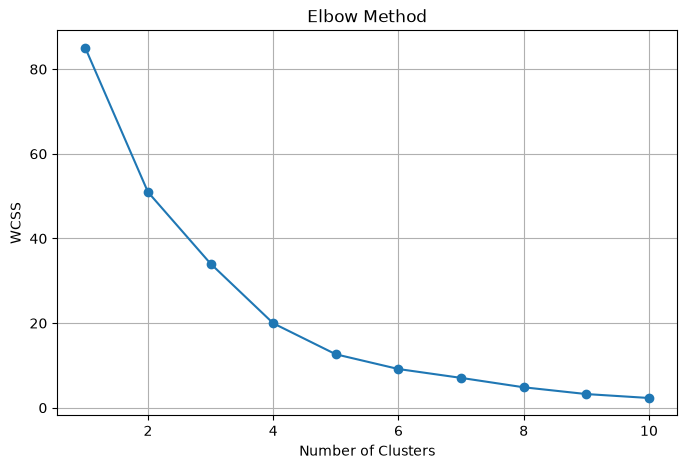

In [53]:
# Find the optimal number of clusters using the Elbow Method
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)
plt.savefig(
    "charts/Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

subcategory_data["Cluster"] = kmeans.fit_predict(
    scaled_features
)

display(subcategory_data)

,Sub-Category,Total_Sales,Average_Sales,Sales_Volatility,Order_Count,Sales_Growth,Cluster
0,Accessories,164186.7000,217.178175,337.723800,756,37.638071,1
1,Appliances,104618.4030,227.926804,378.006735,459,39.927584,0
2,Art,26705.4100,34.019631,60.301752,785,16.605553,0
3,Binders,200028.7850,134.067550,568.099970,1492,21.873607,1
4,Bookcases,113813.1987,503.598224,641.419280,226,23.806516,0
5,Chairs,322822.7310,531.833165,551.180296,607,7.135790,1
6,Copiers,146248.0940,2215.880212,3216.185499,66,84.671819,2
7,Envelopes,16128.0460,65.032444,85.170691,248,-2.766643,0
8,Fasteners,3001.9600,14.027850,12.466864,214,15.703383,0
9,Furnishings,89212.0180,95.823865,148.421490,931,28.788938,0


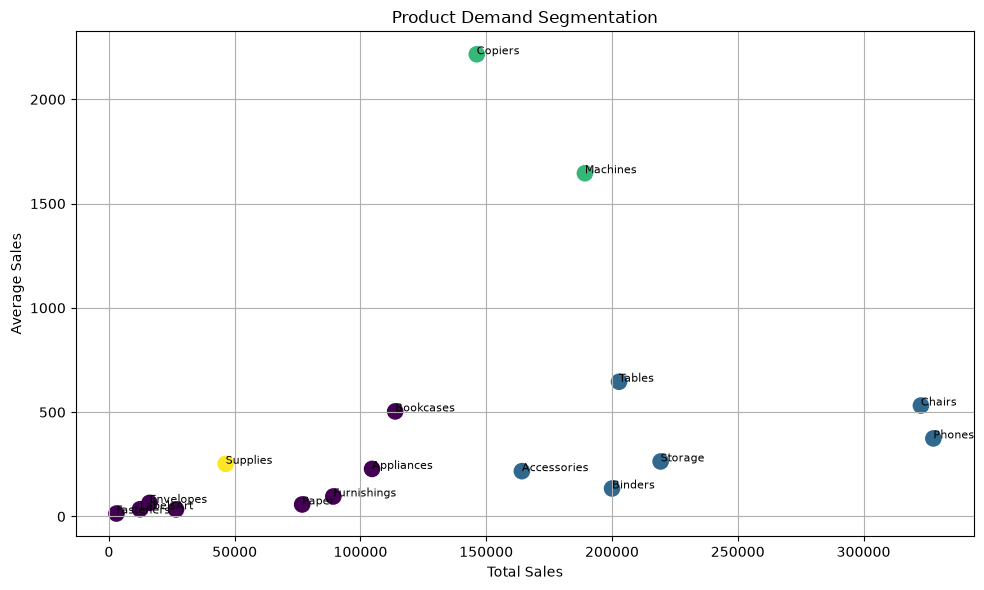

In [55]:
# Visualize the clusters
plt.figure(figsize=(10,6))

plt.scatter(
    subcategory_data["Total_Sales"],
    subcategory_data["Average_Sales"],
    c=subcategory_data["Cluster"],
    s=120
)

for i in range(len(subcategory_data)):
    plt.text(
        subcategory_data["Total_Sales"].iloc[i],
        subcategory_data["Average_Sales"].iloc[i],
        subcategory_data["Sub-Category"].iloc[i],
        fontsize=8
    )

plt.title("Product Demand Segmentation")

plt.xlabel("Total Sales")

plt.ylabel("Average Sales")

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/Product_Demand_Segmentation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [56]:
# Assign business labels to each cluster
cluster_labels = {
    0: "Low Demand",
    1: "Medium Demand",
    2: "High Demand",
    3: "Seasonal Demand"
}

subcategory_data["Demand Segment"] = (
    subcategory_data["Cluster"]
    .map(cluster_labels)
)

display(
    subcategory_data[
        [
            "Sub-Category",
            "Demand Segment"
        ]
    ]
)

,Sub-Category,Demand Segment
0,Accessories,Medium Demand
1,Appliances,Low Demand
2,Art,Low Demand
3,Binders,Medium Demand
4,Bookcases,Low Demand
5,Chairs,Medium Demand
6,Copiers,High Demand
7,Envelopes,Low Demand
8,Fasteners,Low Demand
9,Furnishings,Low Demand


Demand Segment
Low Demand         8
Medium Demand      6
High Demand        2
Seasonal Demand    1
Name: count, dtype: int64

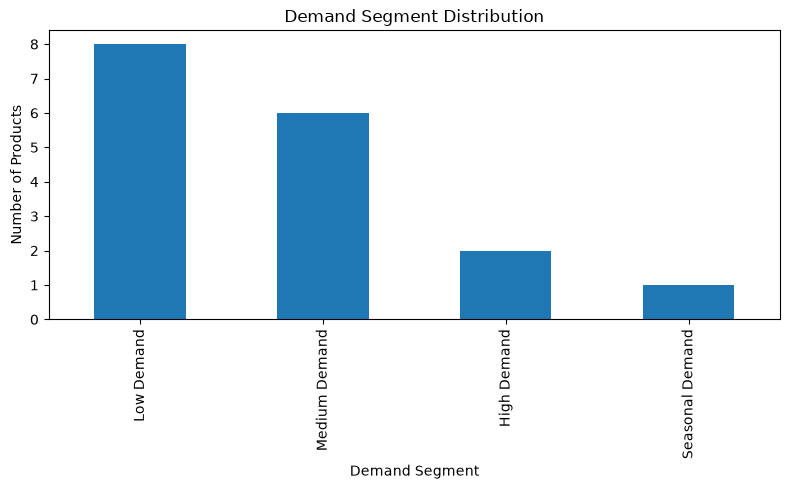

In [57]:
# Count products in each demand segment
segment_count = (
    subcategory_data["Demand Segment"]
    .value_counts()
)

display(segment_count)

segment_count.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Demand Segment Distribution")

plt.xlabel("Demand Segment")

plt.ylabel("Number of Products")

plt.tight_layout()
plt.savefig(
    "charts/Demand_Segment_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# Display the final clustering results
display(
    subcategory_data.sort_values(
        by="Cluster"
    )
)

print("Product demand segmentation completed successfully.")

,Sub-Category,Total_Sales,Average_Sales,Sales_Volatility,Order_Count,Sales_Growth,Cluster,Demand Segment
1,Appliances,104618.4030,227.926804,378.006735,459,39.927584,0,Low Demand
2,Art,26705.4100,34.019631,60.301752,785,16.605553,0,Low Demand
7,Envelopes,16128.0460,65.032444,85.170691,248,-2.766643,0,Low Demand
4,Bookcases,113813.1987,503.598224,641.419280,226,23.806516,0,Low Demand
12,Paper,76828.3040,57.420257,78.492285,1338,25.413074,0,Low Demand
10,Labels,12347.7260,34.587468,74.802711,357,12.192651,0,Low Demand
9,Furnishings,89212.0180,95.823865,148.421490,931,28.788938,0,Low Demand
8,Fasteners,3001.9600,14.027850,12.466864,214,15.703383,0,Low Demand
14,Storage,219343.3920,263.633885,354.907482,832,13.179873,1,Medium Demand
5,Chairs,322822.7310,531.833165,551.180296,607,7.135790,1,Medium Demand


Product demand segmentation completed successfully.


# Task 7 — Interactive Sales Dashboard

In [59]:
# Import the required libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [60]:
# Create monthly sales data
monthly_dashboard = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="MS"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

display(monthly_dashboard.head())

,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [61]:
import os

# Plot monthly sales trend
fig = px.line(
    monthly_dashboard,
    x="Order Date",
    y="Sales",
    title="Monthly Sales Trend"
)
os.makedirs("charts", exist_ok=True)
out_png = "charts/Monthly_Sales_Trend.png"

try:
    fig.write_image(out_png, width=1200, height=600)
except ValueError as e:
    print("Image export failed:", e)
    print("Install kaleido: pip install --upgrade kaleido")
    print("Saving an HTML fallback instead.")
    fig.write_html("charts/Monthly_Sales_Trend.html")
fig.show()


In [62]:
# Plot sales by category
category_dashboard = (
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    category_dashboard,
    x="Category",
    y="Sales",
    title="Sales by Category"
)
try:
    fig.write_image("charts/Sales_by_Category.png", width=1200, height=600)
except ValueError as e:
    print("Image export failed:", e)
    print("Install kaleido: pip install --upgrade kaleido")
    fig.write_html("charts/Sales_by_Category.html")
fig.show()

In [63]:
# Plot sales by region
region_dashboard = (
    df.groupby("Region")["Sales"]
    .sum()
    .reset_index()
)

fig = px.pie(
    region_dashboard,
    names="Region",
    values="Sales",
    title="Regional Sales Distribution"
)
try:
    fig.write_image("charts/Regional_Sales_Distribution.png", width=1200, height=600)
except ValueError as e:
    print("Image export failed:", e)
    print("Install kaleido: pip install --upgrade kaleido")
    fig.write_html("charts/Regional_Sales_Distribution.html")
fig.show()

In [64]:
# Plot monthly sales by category
category_monthly = (
    df.groupby(
        [
            pd.Grouper(key="Order Date", freq="MS"),
            "Category"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

fig = px.line(
    category_monthly,
    x="Order Date",
    y="Sales",
    color="Category",
    title="Monthly Sales by Category"
)
try:
    fig.write_image("charts/monthly_sales_by_category.png", width=1200, height=600)
except ValueError as e:
    print("Image export failed:", e)
    print("Install kaleido: pip install --upgrade kaleido")
    fig.write_html("charts/monthly_sales_by_category.html")
fig.show()

In [65]:
import os

# Display top 10 products by sales
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_products,
    x="Product Name",
    y="Sales",
    title="Top 10 Products by Sales"
)
os.makedirs("charts", exist_ok=True)

try:
    fig.write_image("charts/Top_10_Products_by_Sales.png", width=1200, height=600)
except ValueError as e:
    print("Image export failed:", e)
    print("Install kaleido: pip install --upgrade kaleido")
    fig.write_html("charts/Top_10_Products_by_Sales.html")
fig.show()

# Task 8 — Business Insights & Recommendations

In [66]:
# Identify the best-performing category
best_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .idxmax()
)

print("Best Performing Category:", best_category)

Best Performing Category: Technology


In [67]:
# Identify the best-performing region
best_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .idxmax()
)

print("Best Performing Region:", best_region)

Best Performing Region: West


In [68]:
# Identify the top 10 customers
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [69]:
# Identify the top 10 products
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [70]:
# Display total sales by category
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_by_category)

print(
    "Highest Sales Category:",
    sales_by_category.idxmax()
)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Highest Sales Category: Technology


In [71]:
# Display the category with the lowest sales
print(
    "Lowest Sales Category:",
    sales_by_category.idxmin()
)

Lowest Sales Category: Office Supplies
